# V2 — Data Exploration — BTC/USDT 1H OHLCV

Jan 2022 – Dec 2024  |  Train / Val / Test splits

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = (Path.cwd() / "../.." ).resolve()
sys.path.insert(0, str(PROJECT_ROOT))

import yaml
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from src.data.loader import load_multiple, validate_continuity
from src.data.preprocessor import clean

plt.style.use("seaborn-v0_8-darkgrid")
pd.set_option("display.float_format", "{:,.2f}".format)
print(f"Project root: {PROJECT_ROOT}")


Project root: /Users/nuwan/Work/UoM/MDSAI_2025/semester3/capstone-project/project/reinforcement-based-cryptocurrency-trading-strategy


## 0. Run Data Pipeline

Run once to generate `data/processed/`, `data/features/`, `data/normalized/`.  
Skip if files already exist.


In [2]:
from src.data.pipeline import run as run_pipeline

if not (PROJECT_ROOT / "data/features/train.csv").exists():
    print("Generating files...")
    run_pipeline(config_path=PROJECT_ROOT / "configs/experiment_config.yaml")
else:
    print("Pipeline output already exists — skipping.")


Pipeline output already exists — skipping.


## 1. Load Data

In [3]:
cfg = yaml.safe_load(open(PROJECT_ROOT / "configs/experiment_config.yaml"))
print("Splits:", len(cfg["data"]["train_files"]), "train files,", len(cfg["data"]["val_files"]), "val,", len(cfg["data"]["test_files"]), "test")
print("First train file:", cfg["data"]["train_files"][0])
print("Last  train file:", cfg["data"]["train_files"][-1])

train = load_multiple([PROJECT_ROOT / f for f in cfg["data"]["train_files"]])
val   = load_multiple([PROJECT_ROOT / f for f in cfg["data"]["val_files"]])
test  = load_multiple([PROJECT_ROOT / f for f in cfg["data"]["test_files"]])

all_data = pd.concat([train, val, test]).sort_index()

print(f"Total rows : {len(all_data):,}")
print(f"Date range : {all_data.index[0].date()} -> {all_data.index[-1].date()}")
print(f"Split sizes: train={len(train):,}  val={len(val):,}  test={len(test):,}")
print("Price range: USD", f"{all_data.close.min():,.0f}", "-", f"{all_data.close.max():,.0f}")


Splits: 32 train files, 1 val, 3 test
First train file: data/raw/1h/BTCUSDT-1h-2022-01.csv
Last  train file: data/raw/1h/BTCUSDT-1h-2024-08.csv
Total rows : 26,303
Date range : 2022-01-01 -> 2024-12-31
Split sizes: train=23,375  val=720  test=2,208
Price range: USD 15,650 - 108,258


## 2. Basic Statistics

In [4]:
all_data.describe()

,open,high,low,close,volume
count,"26,303.00","26,303.00","26,303.00","26,303.00","26,303.00"
mean,"40,997.66","41,151.89","40,837.81","40,999.46","3,915.43"
std,"20,709.74","20,789.07","20,625.53","20,712.25","5,705.35"
min,"15,648.23","15,769.99","15,476.00","15,649.52",0.00
25%,"24,763.43","24,885.22","24,641.38","24,764.08",844.92
50%,"35,046.07","35,207.00","34,867.14","35,046.06","1,632.00"
75%,"59,040.01","59,264.56","58,819.54","59,041.99","4,699.48"
max,"108,258.38","108,353.00","107,130.00","108,258.39","137,207.19"


In [5]:
# Monthly summary — close price stats per month
monthly = all_data["close"].resample("ME").agg(["min","max","mean","std"])
monthly.index = monthly.index.strftime("%Y-%m")
monthly.columns = ["Min ($)", "Max ($)", "Mean ($)", "Std Dev ($)"]
monthly


,Min ($),Max ($),Mean ($),Std Dev ($)
open_time,,,,
2022-01,"33,114.90","47,792.30","41,135.77","3,639.89"
2022-02,"34,680.85","45,382.86","40,588.49","2,543.32"
2022-03,"37,308.94","47,970.99","41,925.74","2,830.14"
2022-04,"37,630.80","46,980.00","41,611.53","2,509.31"
2022-05,"27,114.84","39,859.22","31,864.67","3,454.31"
2022-06,"17,809.00","31,936.54","24,475.13","4,565.75"
2022-07,"18,977.22","24,577.29","21,442.83","1,494.04"
2022-08,"19,555.61","24,917.72","22,467.40","1,484.47"
2022-09,"18,389.22","22,531.18","19,815.02",902.65


## 3. Price Chart with Train / Val / Test Splits

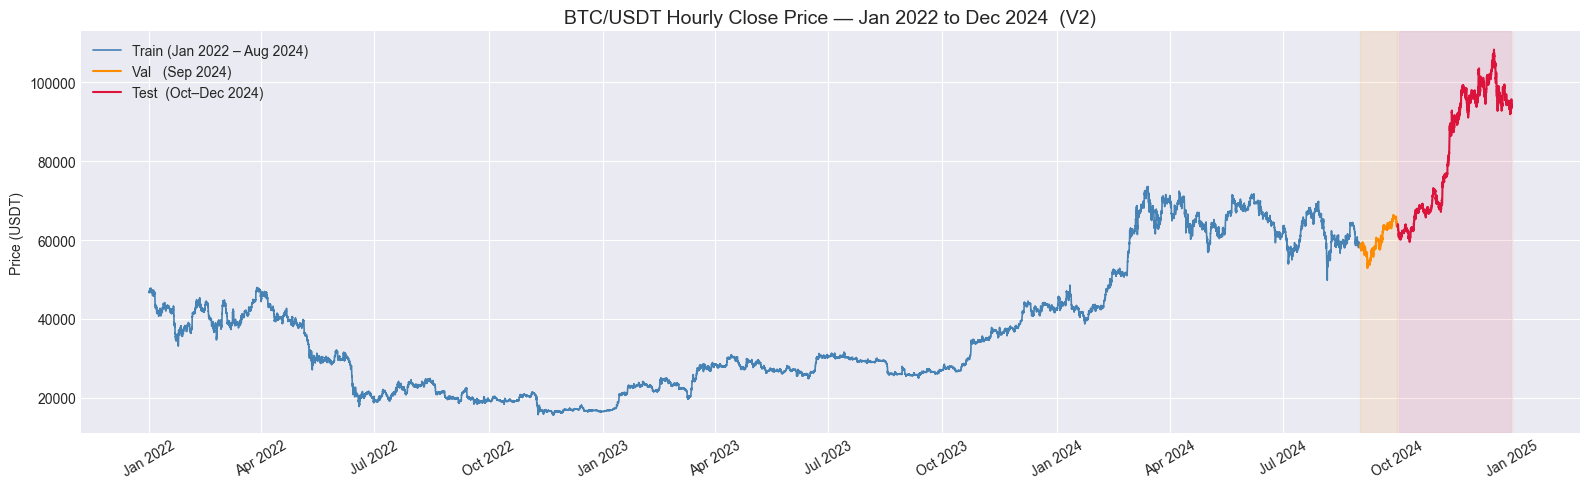

In [6]:
fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(train.index, train["close"], color="steelblue",  label="Train (Jan 2022 – Aug 2024)", linewidth=1.2)
ax.plot(val.index,   val["close"],   color="darkorange", label="Val   (Sep 2024)",             linewidth=1.5)
ax.plot(test.index,  test["close"],  color="crimson",    label="Test  (Oct–Dec 2024)",         linewidth=1.5)

ax.axvspan(val.index[0],  val.index[-1],  alpha=0.10, color="darkorange")
ax.axvspan(test.index[0], test.index[-1], alpha=0.10, color="crimson")

ax.set_title("BTC/USDT Hourly Close Price — Jan 2022 to Dec 2024  (V2)", fontsize=14)
ax.set_ylabel("Price (USDT)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1,4,7,10]))
plt.xticks(rotation=30)
ax.legend()
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "results/figures/v2_01_price_splits.png", dpi=150)
plt.show()


## 4. Volume

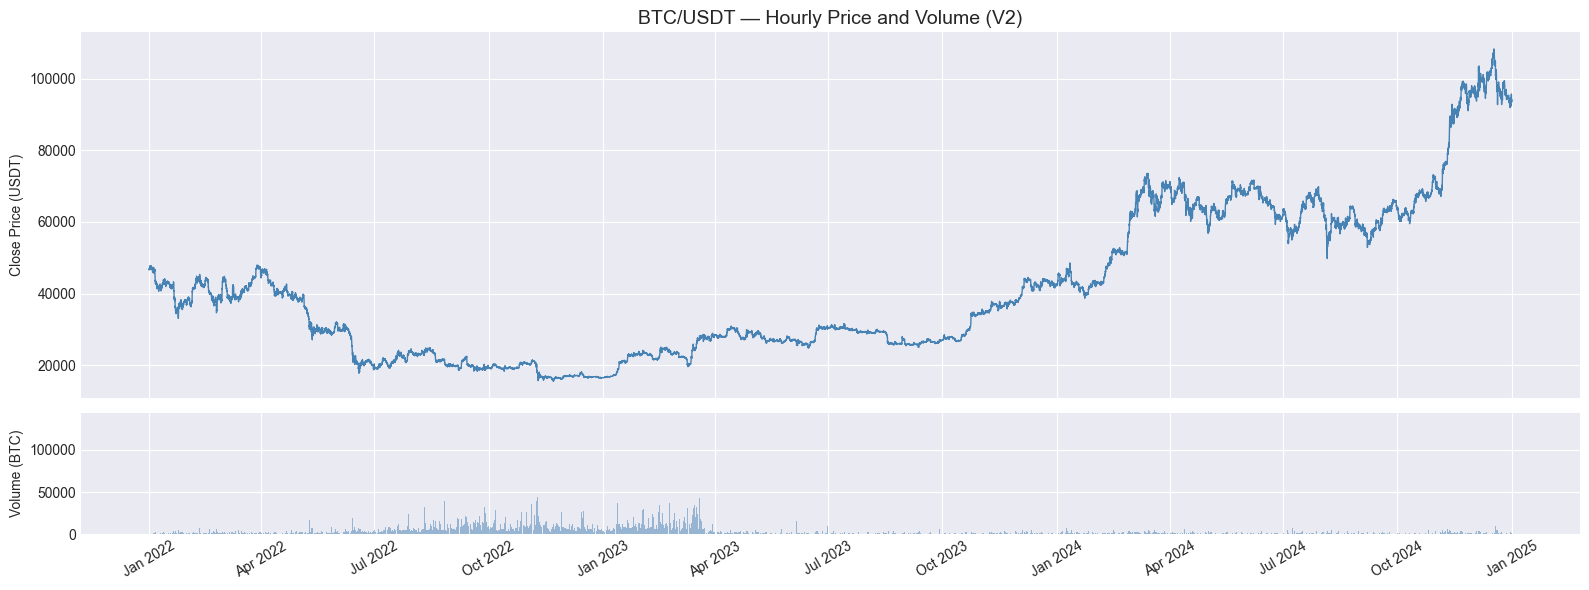

In [7]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 6), sharex=True, gridspec_kw={"height_ratios": [3, 1]})

ax1.plot(all_data.index, all_data["close"], color="steelblue", linewidth=1.0)
ax1.set_ylabel("Close Price (USDT)")
ax1.set_title("BTC/USDT — Hourly Price and Volume (V2)", fontsize=14)

ax2.bar(all_data.index, all_data["volume"], color="steelblue", alpha=0.5, width=0.04)
ax2.set_ylabel("Volume (BTC)")
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax2.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1,4,7,10]))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "results/figures/v2_01_price_volume.png", dpi=150)
plt.show()


## 5. Hourly Returns Distribution

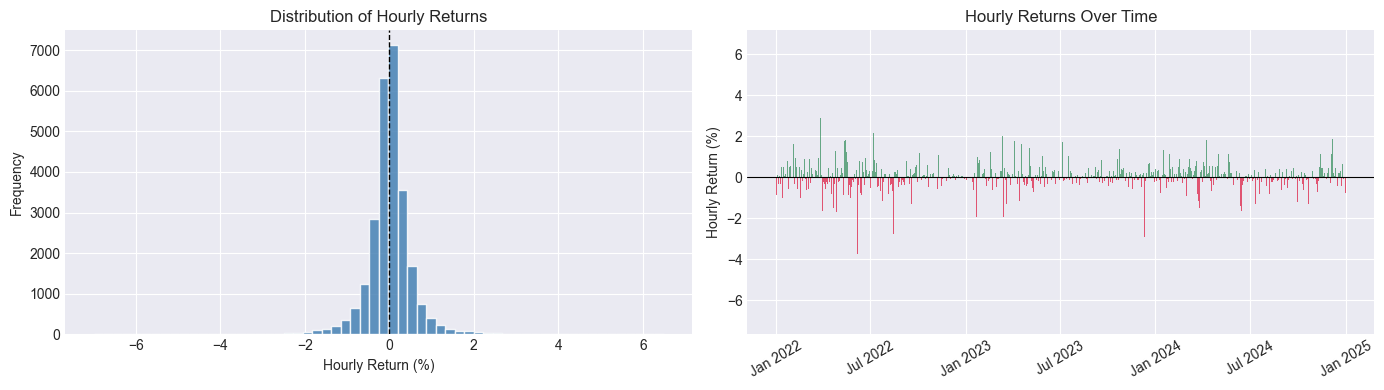

Mean hourly return : 0.0043%
Std  hourly return : 0.5733%
Max gain  (hourly) : 6.49%
Max loss  (hourly) : -6.99%
Positive hours     : 13,347 / 26,302


In [8]:
hourly_returns = all_data["close"].pct_change().dropna() * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.hist(hourly_returns, bins=60, color="steelblue", edgecolor="white", alpha=0.85)
ax1.axvline(0, color="black", linewidth=1, linestyle="--")
ax1.set_xlabel("Hourly Return (%)")
ax1.set_ylabel("Frequency")
ax1.set_title("Distribution of Hourly Returns")

ax2.bar(hourly_returns.index, hourly_returns,
        color=["crimson" if r < 0 else "seagreen" for r in hourly_returns],
        width=0.04, alpha=0.7)
ax2.axhline(0, color="black", linewidth=0.8)
ax2.set_ylabel("Hourly Return (%)")
ax2.set_title("Hourly Returns Over Time")
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax2.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1,7]))
plt.xticks(rotation=30)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "results/figures/v2_01_hourly_returns.png", dpi=150)
plt.show()

print(f"Mean hourly return : {hourly_returns.mean():.4f}%")
print(f"Std  hourly return : {hourly_returns.std():.4f}%")
print(f"Max gain  (hourly) : {hourly_returns.max():.2f}%")
print(f"Max loss  (hourly) : {hourly_returns.min():.2f}%")
print(f"Positive hours     : {(hourly_returns > 0).sum():,} / {len(hourly_returns):,}")


## 6. Market Regime Summary

In [9]:
train_feat = pd.read_csv(PROJECT_ROOT / "data/features/train.csv", index_col=0, parse_dates=True)

print("Annual close price ranges in training data:")
for year in [2022, 2023, 2024]:
    yr = train_feat[train_feat.index.year == year]["close"]
    if not yr.empty:
        chg = (yr.iloc[-1] / yr.iloc[0] - 1) * 100
        print(f"  {year}: ${yr.min():,.0f} – ${yr.max():,.0f}   YoY change: {chg:+.1f}%  ({len(yr):,} rows)")


Annual close price ranges in training data:
  2022: $15,650 – $47,971   YoY change: -64.9%  (8,711 rows)
  2023: $16,513 – $44,527   YoY change: +155.8%  (8,759 rows)
  2024: $38,768 – $73,577   YoY change: +38.8%  (5,856 rows)
